<a href="https://colab.research.google.com/github/M-AdityoRahman/PCVK_Ganjil_2025/blob/main/week6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

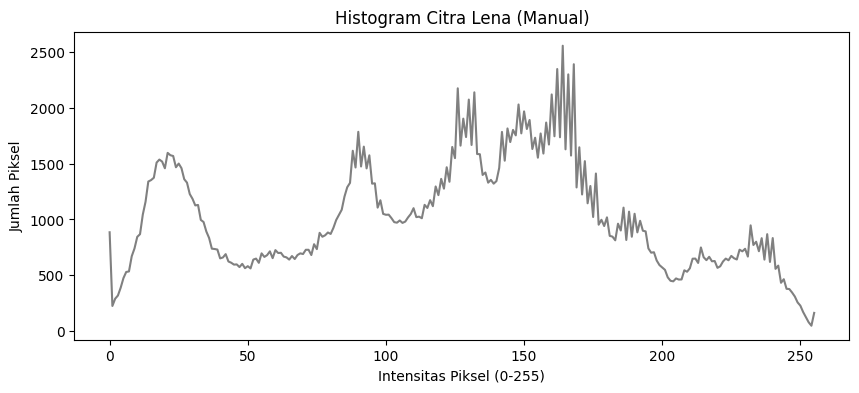

In [2]:
# Baca citra grayscale
img = cv.imread('/content/drive/MyDrive/PCVK/lena.jpg', cv.IMREAD_GRAYSCALE)

# Hitung kemunculan tiap intensitas pixel
hist = np.zeros(256)
for pixel in img.ravel():
    hist[pixel] += 1

# Tampilkan histogram
plt.figure(figsize=(10,4))
plt.title("Histogram Citra Lena (Manual)")
plt.xlabel("Intensitas Piksel (0-255)")
plt.ylabel("Jumlah Piksel")
plt.plot(hist, color='gray')
plt.show()


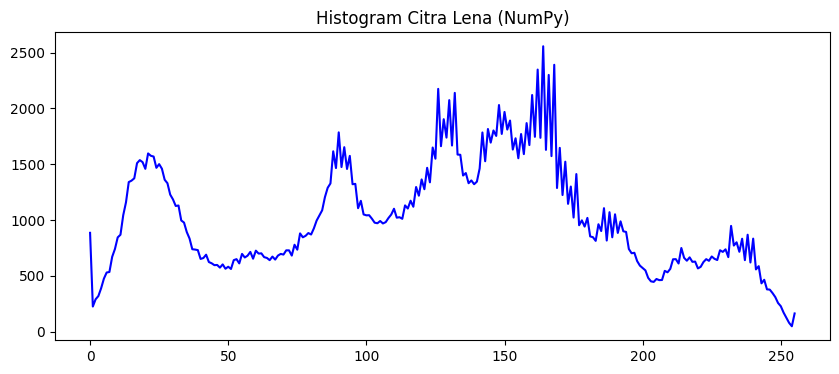

In [3]:
# Hitung histogram menggunakan fungsi bawaan NumPy
hist_np, bins = np.histogram(img.flatten(), 256, [0,256])

# Tampilkan
plt.figure(figsize=(10,4))
plt.title("Histogram Citra Lena (NumPy)")
plt.plot(hist_np, color='blue')
plt.show()


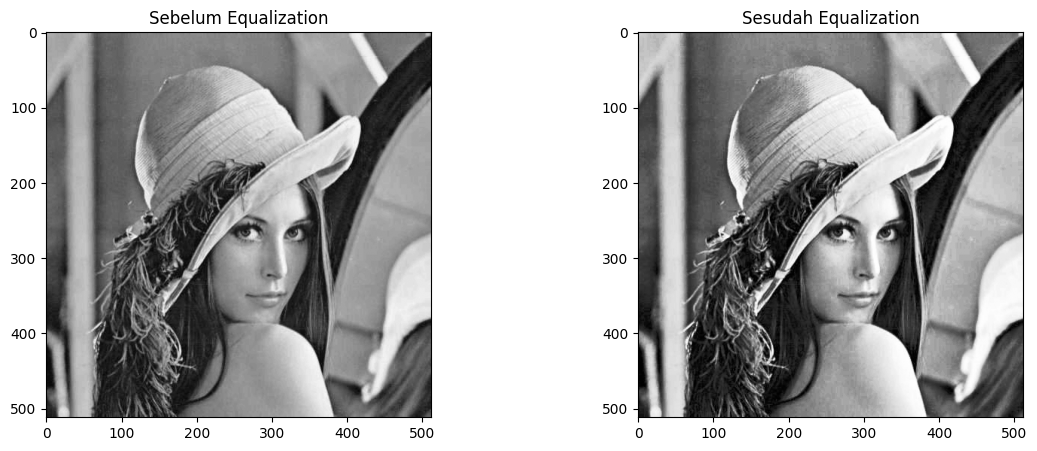

In [4]:
img_lc = cv.imread('/content/drive/MyDrive/PCVK/lena_lc.jpg', cv.IMREAD_GRAYSCALE)

# Hitung histogram normalisasi dan distribusi kumulatif
hist, _ = np.histogram(img_lc.flatten(), 256, [0,256])
cdf = hist.cumsum()
cdf_normalized = cdf * hist.max()/cdf.max()

# Transformasi equalization
cdf_m = np.ma.masked_equal(cdf, 0)
cdf_m = (cdf_m - cdf_m.min())*255/(cdf_m.max()-cdf_m.min())
cdf_final = np.ma.filled(cdf_m,0).astype('uint8')
img_eq = cdf_final[img_lc]

# Tampilkan hasil
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.imshow(img_lc, cmap='gray')
plt.title("Sebelum Equalization")

plt.subplot(1,2,2)
plt.imshow(img_eq, cmap='gray')
plt.title("Sesudah Equalization")
plt.show()


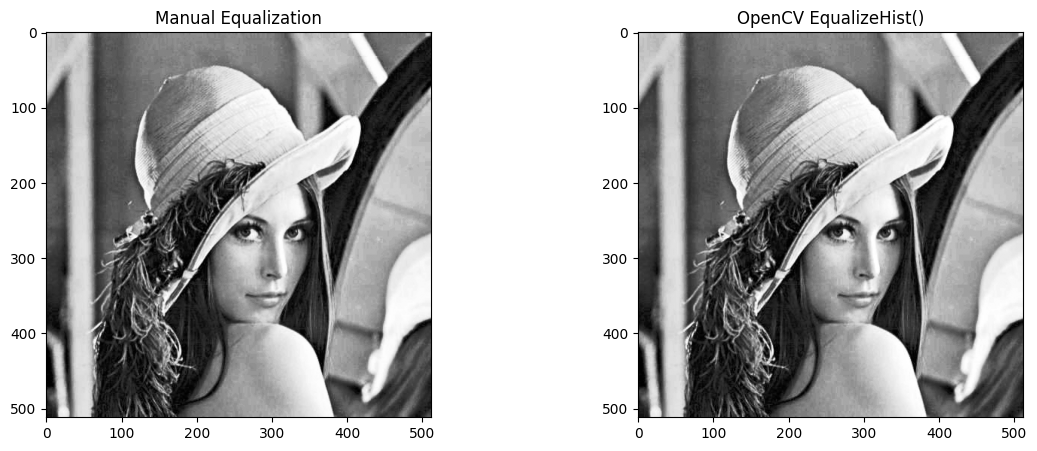

In [5]:
# Equalization built-in OpenCV
img_cv_eq = cv.equalizeHist(img_lc)

# Bandingkan
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.imshow(img_eq, cmap='gray')
plt.title("Manual Equalization")

plt.subplot(1,2,2)
plt.imshow(img_cv_eq, cmap='gray')
plt.title("OpenCV EqualizeHist()")
plt.show()


Hasilnya nyaris identik dengan metode manual, karena fungsi cv.equalizeHist() menggunakan logika yang sama untuk mendistribusikan nilai keabuan secara merata.
Perbedaannya hanya di optimasi internal (lebih cepat dan stabil).

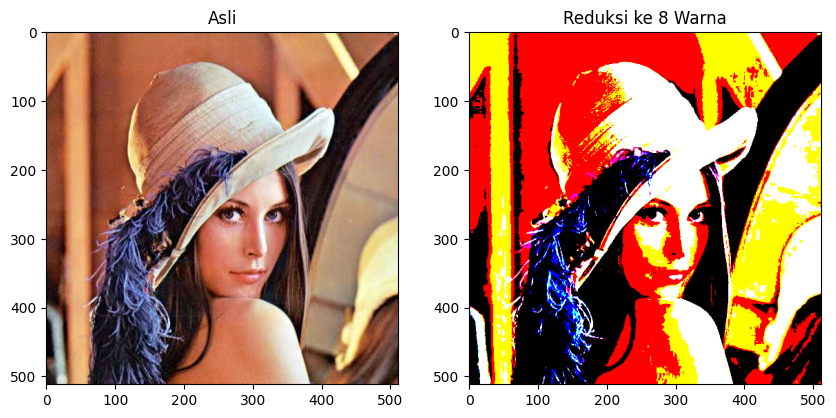

In [6]:
# Baca gambar warna
img_color = cv.imread('/content/drive/MyDrive/PCVK/lena.jpg')
img_rgb = cv.cvtColor(img_color, cv.COLOR_BGR2RGB)

# Tentukan warna dasar (8 warna)
warna_dasar = np.array([
    [0, 0, 0],        # Hitam
    [255, 0, 0],      # Merah
    [0, 255, 0],      # Hijau
    [0, 0, 255],      # Biru
    [255, 255, 0],    # Kuning
    [0, 255, 255],    # Cyan
    [255, 0, 255],    # Magenta
    [255, 255, 255]   # Putih
])

# Mapping warna terdekat
hasil = np.zeros_like(img_rgb)
for i in range(img_rgb.shape[0]):
    for j in range(img_rgb.shape[1]):
        pixel = img_rgb[i,j]
        idx = np.argmin(np.sum((warna_dasar - pixel)**2, axis=1))
        hasil[i,j] = warna_dasar[idx]

plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(img_rgb); plt.title("Asli")
plt.subplot(1,2,2); plt.imshow(hasil); plt.title("Reduksi ke 8 Warna")
plt.show()


Citra berubah menjadi tampilan poster-like (seperti komik).
Proses ini disebut color quantization, di mana setiap piksel diganti dengan warna dasar terdekat untuk mengurangi kompleksitas warna.

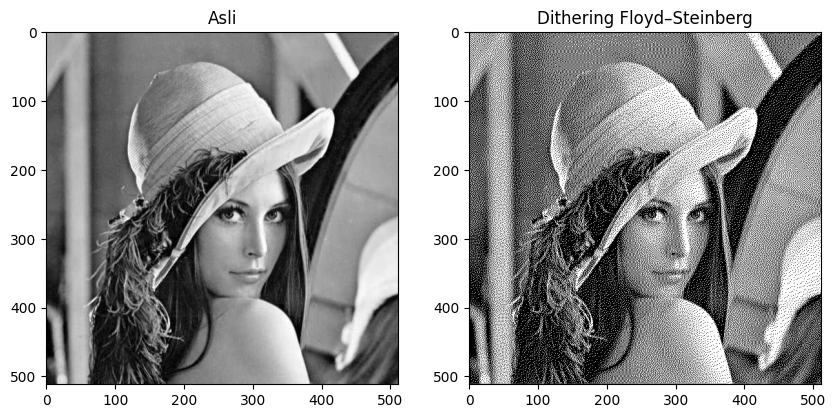

In [7]:
# Konversi ke grayscale
img = cv.imread('/content/drive/MyDrive/PCVK/lena.jpg', cv.IMREAD_GRAYSCALE)
img = img.astype(float) / 255.0

# Floyd–Steinberg kernel
h, w = img.shape
for y in range(h-1):
    for x in range(1, w-1):
        old_pixel = img[y, x]
        new_pixel = np.round(old_pixel)
        img[y, x] = new_pixel
        error = old_pixel - new_pixel

        img[y, x+1] += error * 7/16
        img[y+1, x-1] += error * 3/16
        img[y+1, x] += error * 5/16
        img[y+1, x+1] += error * 1/16

img_dither = np.clip(img, 0, 1)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1); plt.imshow(cv.imread('/content/drive/MyDrive/PCVK/lena.jpg', cv.IMREAD_GRAYSCALE), cmap='gray'); plt.title("Asli")
plt.subplot(1,2,2); plt.imshow(img_dither, cmap='gray'); plt.title("Dithering Floyd–Steinberg")
plt.show()


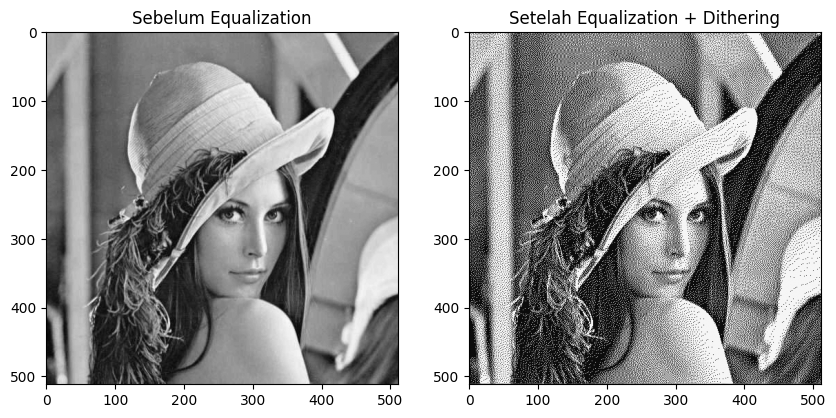

In [8]:
# Histogram equalization lalu dithering
img_lc = cv.imread('/content/drive/MyDrive/PCVK/lena_lc.jpg', cv.IMREAD_GRAYSCALE)
img_eq = cv.equalizeHist(img_lc).astype(float) / 255.0

for y in range(img_eq.shape[0]-1):
    for x in range(1, img_eq.shape[1]-1):
        old_pixel = img_eq[y, x]
        new_pixel = np.round(old_pixel)
        img_eq[y, x] = new_pixel
        error = old_pixel - new_pixel
        img_eq[y, x+1] += error * 7/16
        img_eq[y+1, x-1] += error * 3/16
        img_eq[y+1, x] += error * 5/16
        img_eq[y+1, x+1] += error * 1/16

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(cv.imread('/content/drive/MyDrive/PCVK/lena_lc.jpg', cv.IMREAD_GRAYSCALE), cmap='gray')
plt.title("Sebelum Equalization")

plt.subplot(1,2,2)
plt.imshow(img_eq, cmap='gray')
plt.title("Setelah Equalization + Dithering")
plt.show()


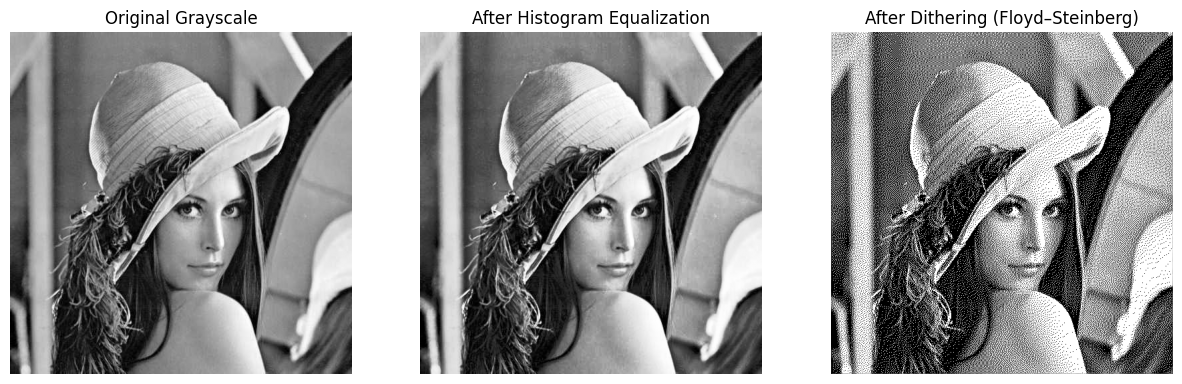

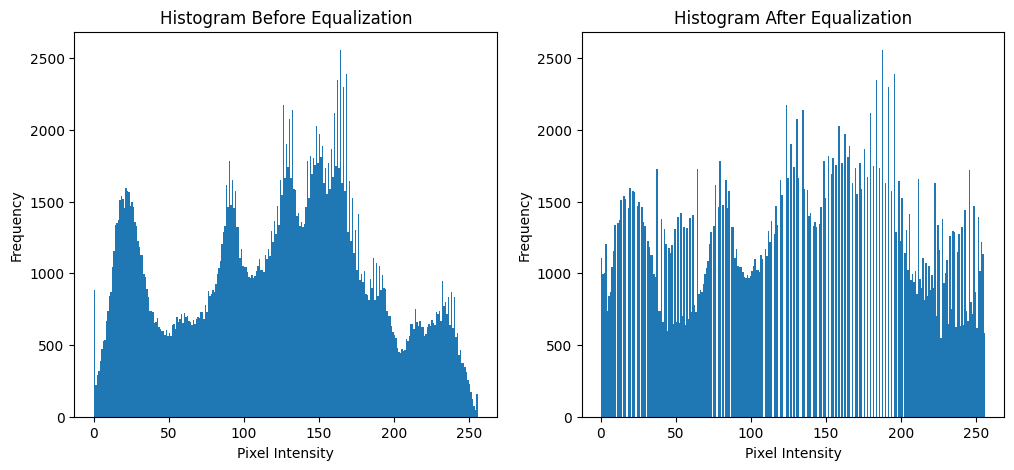

In [12]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# 1. Baca gambar lena_lc dan konversi ke grayscale
img = cv.imread('/content/drive/MyDrive/PCVK/lena.jpg', cv.IMREAD_GRAYSCALE)

# 2. Histogram Equalization
equalized = cv.equalizeHist(img)

# 3. Floyd–Steinberg Dithering
dithered = equalized.astype(float)
h, w = dithered.shape

for y in range(h-1):
    for x in range(1, w-1):
        old_pixel = dithered[y, x]
        new_pixel = 255 if old_pixel > 128 else 0  # threshold biner
        dithered[y, x] = new_pixel
        error = old_pixel - new_pixel

        # Sebarkan error ke tetangga (kernel Floyd–Steinberg)
        dithered[y, x+1]     += error * 7/16
        dithered[y+1, x-1]   += error * 3/16
        dithered[y+1, x]     += error * 5/16
        dithered[y+1, x+1]   += error * 1/16

# Pastikan nilai pixel valid
dithered = np.clip(dithered, 0, 255).astype(np.uint8)

# 4. Tampilkan gambar
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original Grayscale")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(equalized, cmap='gray')
plt.title("After Histogram Equalization")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(dithered, cmap='gray')
plt.title("After Dithering (Floyd–Steinberg)")
plt.axis("off")
plt.show()

# 5. Tampilkan histogram sebelum & sesudah equalization
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(img.ravel(), bins=256, range=[0,256])
plt.title("Histogram Before Equalization")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
plt.hist(equalized.ravel(), bins=256, range=[0,256])
plt.title("Histogram After Equalization")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()